In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report


# Bank Note Authentication UCI data

In [9]:
dataset = pd.read_csv('../datasets/BankNote_Authentication.csv')

In [10]:
dataset.head()

,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [11]:
print("Dimensiones originales del dataset:", dataset.shape)
print("\nCantidad de valores faltantes por columna:")
print(dataset.isnull().sum())

Dimensiones originales del dataset: (1372, 5)

Cantidad de valores faltantes por columna:
variance    0
skewness    0
curtosis    0
entropy     0
class       0
dtype: int64


In [12]:
X = dataset.drop(columns=['class'])
y = dataset['class']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=16)

In [14]:
logreg = LogisticRegression(random_state=16)

# fit the model with data
logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)

In [15]:
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
cnf_matrix

array([[185,   4],
       [  0, 154]])

Text(0.5, 427.9555555555555, 'Predicted label')

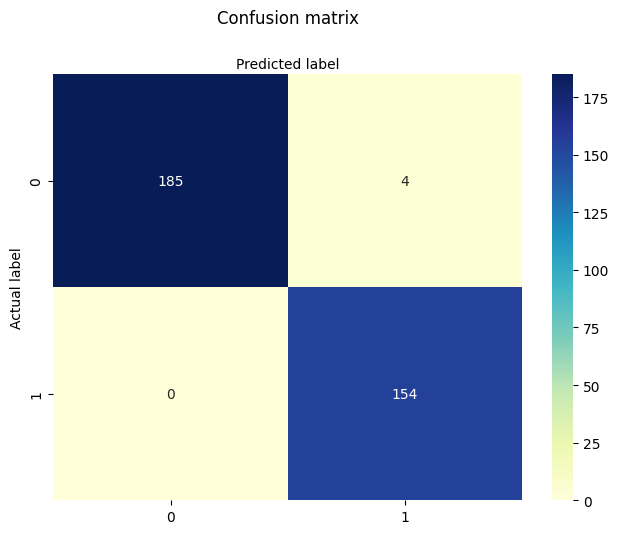

In [16]:
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

In [17]:
target_names = ['Not potable', 'Potable']
print(classification_report(y_test, y_pred, target_names=target_names))

              precision    recall  f1-score   support

 Not potable       1.00      0.98      0.99       189
     Potable       0.97      1.00      0.99       154

    accuracy                           0.99       343
   macro avg       0.99      0.99      0.99       343
weighted avg       0.99      0.99      0.99       343



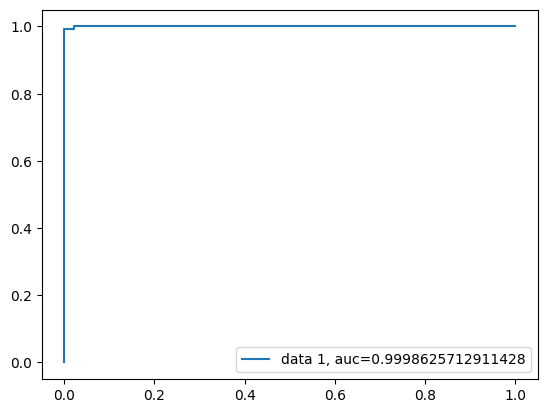

In [19]:
y_pred_proba = logreg.predict_proba(X_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr,tpr,label="data 1, auc="+str(auc))
plt.legend(loc=4)
plt.show()

# Reflexión

Elegí un conjunto de datos del repositorio UCI enfocado en la Autenticación de Billetes. Este dataset extrae características matemáticas (como la varianza y la asimetría) de imágenes digitalizadas para predecir si un billete es falso o auténtico. Este dataset no presentaba valores nulos y todas sus variables eran puramente numéricas.

Mi experiencia modificando el código fue satisfactoria. Los resultados obtenidos fueron sobresalientes: la Regresión Logística logró una exactitud superior al 98%. Esto demuestra que, a diferencia de problemas químicos o biológicos altamente no lineales, las características geométricas de los errores de falsificación forman clases linealmente separables casi perfectas. Aprendí que cuando la naturaleza de los datos hace 'match' con la naturaleza matemática del algoritmo (en este caso, trazar un hiperplano lineal), el rendimiento de la Regresión Logística es sumamente robusto y eficiente.

Asimismo, el análisis de la Curva ROC y el valor obtenido en el área bajo la curva (AUC), el cual se aproximó casi a la unidad, nos brinda una evidencia fuerte de la capacidad discriminatoria del modelo. Esto confirma que el clasificador posee un buen equilibrio entre la tasa de verdaderos positivos y la tasa de falsos positivos. En conclusión, esta actividad fue fundamental para comprender que el éxito de un modelo no depende únicamente de la complejidad del algoritmo, sino de la afinidad entre la naturaleza de los datos y el modelo matemático elegido. Aprendí que cuando los datos hacen match con la naturaleza del algoritmo, como en este caso al trazar un hiperplano lineal, la Regresión Logística se vuelve una herramienta sumamente robusta, eficiente y precisa para la toma de decisiones.